In [28]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

data = fetch_california_housing()

X = pd.DataFrame(data.data , columns=data.feature_names)
y = pd.Series(data.target, name="price")

df = pd.concat([X, y], axis=1)
        
df.to_csv("california_housing.csv", index=False)

epoch 1 of 200 | loss : 4.917762756347656
epoch 11 of 200 | loss : 3.791857957839966
epoch 21 of 200 | loss : 2.7719316482543945
epoch 31 of 200 | loss : 1.8786640167236328
epoch 41 of 200 | loss : 1.2012132406234741
epoch 51 of 200 | loss : 0.7633404731750488
epoch 61 of 200 | loss : 0.5591660141944885
epoch 71 of 200 | loss : 0.521920382976532
epoch 81 of 200 | loss : 0.5259034633636475
epoch 91 of 200 | loss : 0.5237520933151245
epoch 101 of 200 | loss : 0.5205544233322144
epoch 111 of 200 | loss : 0.5200314521789551
epoch 121 of 200 | loss : 0.5200673937797546
epoch 131 of 200 | loss : 0.5199800729751587
epoch 141 of 200 | loss : 0.5199472308158875
epoch 151 of 200 | loss : 0.5199434757232666
epoch 161 of 200 | loss : 0.5199403166770935
epoch 171 of 200 | loss : 0.5199386477470398
epoch 181 of 200 | loss : 0.5199384093284607
epoch 191 of 200 | loss : 0.5199382305145264
epoch 201 of 200 | loss : 0.5199381709098816
✅ Model Saved


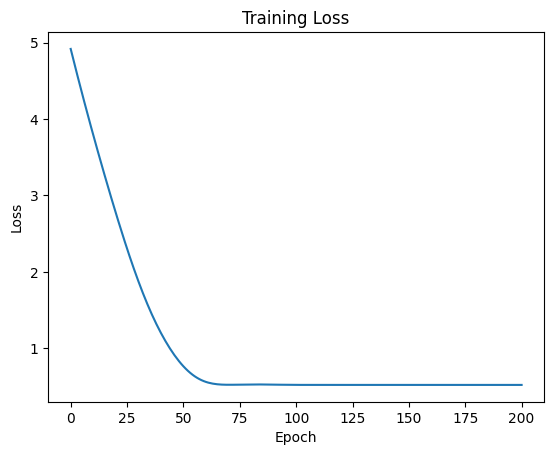

In [29]:

import torch
import pandas as pd 
from torch import nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

data = pd.read_csv('../data/california_housing.csv')

device = "cuda" if torch.cuda.is_available() else "cpu"

X = data.drop('price' , axis=1).values
y = data['price'].values.reshape(-1,1)

model = LinearRegression(len(X[0])).to(device)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)


scaler_instance = StandardScaler()
X_train = scaler_instance.fit_transform(X_train) 
X_test = scaler_instance.transform(X_test)  


loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(params=model.parameters() , lr=0.003)

X_train = torch.from_numpy(X_train).type(torch.float)
X_test = torch.from_numpy(X_test).type(torch.float)
y_train = torch.from_numpy(y_train).type(torch.float)
y_test = torch.from_numpy(y_test).type(torch.float)

# building the train function

losses = []
epochs = 200

X_train , X_test = X_train.to(device) , X_test.to(device)
y_train , y_test = y_train.to(device) , y_test.to(device)



for epoch in range(epochs +  1) :
    model.train()

    y_preds = model(X_train)
    
    loss = loss_fn(y_preds , y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    
    if epoch % 10 == 0 :
        print(f'epoch {epoch+1} of {epochs} | loss : {loss}')

    losses.append(loss)
# saving the models into the models folder
torch.save(model.state_dict(),"../models/model.pth")
print("✅ Model Saved")


# plot and saving the plot
numpy_losses = np.array([l.cpu().detach().item() if hasattr(l, 'cpu') else l for l in losses])
plt.plot(numpy_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.savefig("loss_curve.png")
plt.show()

In [30]:

import torch

from model import LinearRegression

data = pd.read_csv('../data/california_housing.csv')


X = data.drop('price' , axis=1).values
y = data['price'].values.reshape(-1,1)

model = LinearRegression(len(X[0])).to(device)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)


scaler_instance = StandardScaler()
X_train = scaler_instance.fit_transform(X_train) 
X_test = scaler_instance.transform(X_test)  


X_train = torch.from_numpy(X_train).type(torch.float)
X_test = torch.from_numpy(X_test).type(torch.float)
y_train = torch.from_numpy(y_train).type(torch.float)
y_test = torch.from_numpy(y_test).type(torch.float)

loss_fn = nn.MSELoss()

# building the predict function


model = LinearRegression(len(X[0]))
model.load_state_dict(torch.load('../models/model.pth'))

model.eval()
with torch.inference_mode():
    y_pred = model(X_test)
    test_loss = loss_fn(y_pred , y_test)

print(f"test_loss : {test_loss}")    

test_loss : 0.5369756817817688
